# 사이킷런으로 구현해 보는 머신러닝

## Goal

이 notebook(노트북)은 MODULABS 수업의 설명을 따라 선형회귀와 와인 분류를 로컬에서 직접 실행하는 tutorial(튜토리얼)입니다.

> LMS에서 복사된 자료에는 코드 셀 본문이 포함되지 않아, 자료에 명시된 API와 실행 순서를 현재 scikit-learn에 맞게 복원했습니다.

## Setup

필요한 library(라이브러리)를 불러오고 실제 실행 버전을 확인합니다.

In [1]:
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split

print(f"Python executable: {sys.executable}")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python executable: /Users/yongza/300억/PRI_AI/scikit-learn-basics/.venv/bin/python
Python: 3.12.9
NumPy: 2.5.2
Pandas: 3.0.5
Matplotlib: 3.11.1
scikit-learn: 1.9.0


## Steps

### 1. Feature Matrix(특성 행렬)와 Target Vector(타겟 벡터)

- `X`: 입력 데이터이며 `[n_samples, n_features]` 모양의 2차원 배열입니다.
- `y`: 정답 데이터이며 이 실습에서는 `[n_samples]` 모양의 1차원 배열입니다.

In [2]:
random_generator = np.random.default_rng(42)
x = 10 * random_generator.random(100)
y_regression = 2 * x - 1 + random_generator.normal(size=100)

print(f"x shape: {x.shape}")
print(f"y shape: {y_regression.shape}")

x shape: (100,)
y shape: (100,)


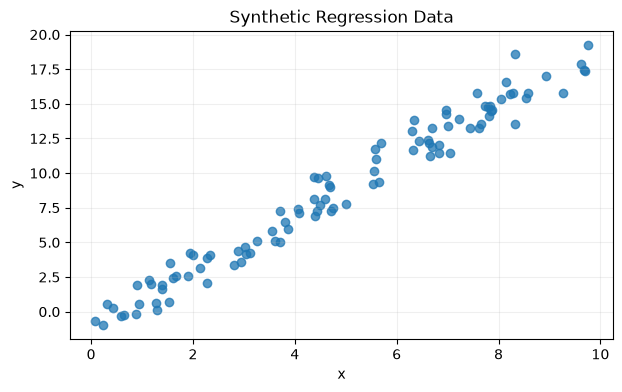

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y_regression, alpha=0.75)
plt.title("Synthetic Regression Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.2)
plt.show()

`LinearRegression.fit()`에 1차원 `x`를 그대로 넣으면 Feature Matrix가 아니므로 `ValueError`가 발생합니다. 아래 셀은 이 expected error(예상 오류)를 안전하게 확인합니다.

In [4]:
invalid_model = LinearRegression()
try:
    invalid_model.fit(x, y_regression)
except ValueError as error:
    print(f"예상된 오류: {type(error).__name__}")
    print(str(error).splitlines()[0])
else:
    raise AssertionError("1차원 입력에서 ValueError가 발생해야 합니다.")

예상된 오류: ValueError
Expected 2D array, got 1D array instead:


`reshape(-1, 1)`로 100개의 sample(표본)과 1개의 feature(특성)를 가진 행렬을 만듭니다.

In [5]:
X_regression = x.reshape(-1, 1)
regression_model = LinearRegression()
regression_model.fit(X_regression, y_regression)

print(f"X shape: {X_regression.shape}")
print(f"coefficient: {regression_model.coef_[0]:.4f}")
print(f"intercept: {regression_model.intercept_:.4f}")

X shape: (100, 1)
coefficient: 2.0077
intercept: -1.0513


In [6]:
x_new = np.linspace(0, 10, 100)
X_new = x_new.reshape(-1, 1)
y_prediction_line = regression_model.predict(X_new)

print(f"prediction input shape: {X_new.shape}")
print(f"reshape tip - (2, -1): {x_new.reshape(2, -1).shape}")

prediction input shape: (100, 1)
reshape tip - (2, -1): (2, 50)


수업의 방식처럼 `sqrt(MSE)`로 RMSE를 계산하고, 현재 API인 `root_mean_squared_error()`와 값이 같은지 확인합니다.

In [7]:
training_predictions = regression_model.predict(X_regression)
mse = mean_squared_error(y_regression, training_predictions)
rmse_from_formula = np.sqrt(mse)
rmse_from_api = root_mean_squared_error(y_regression, training_predictions)

print(f"MSE: {mse:.4f}")
print(f"RMSE (sqrt): {rmse_from_formula:.4f}")
print(f"RMSE (API): {rmse_from_api:.4f}")
assert np.isclose(rmse_from_formula, rmse_from_api)

MSE: 0.9589
RMSE (sqrt): 0.9792
RMSE (API): 0.9792


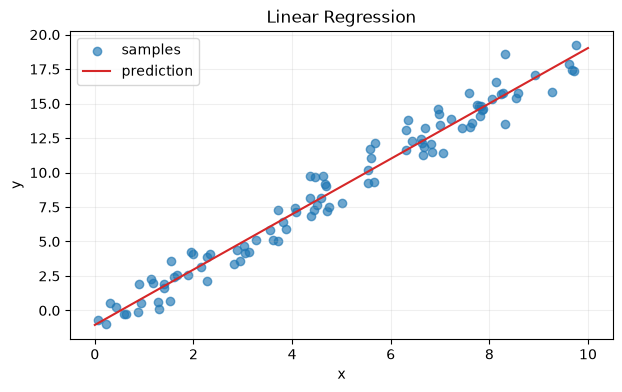

In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y_regression, alpha=0.65, label="samples")
plt.plot(x_new, y_prediction_line, color="tab:red", label="prediction")
plt.title("Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### 2. `datasets.load_wine()` 살펴보기

`load_wine()`은 별도 다운로드가 필요 없는 Toy Dataset(소형 내장 데이터셋)입니다. 반환값은 dictionary(딕셔너리)처럼 사용할 수 있는 `Bunch`입니다.

In [9]:
wine = load_wine()

print(f"type: {type(wine)}")
print(f"keys: {list(wine.keys())}")
print(f"data shape: {wine.data.shape}, ndim: {wine.data.ndim}")
print(f"target shape: {wine.target.shape}, ndim: {wine.target.ndim}")
print(f"feature count: {len(wine.feature_names)}")
print(f"target names: {wine.target_names}")
print("\nDESCR preview:")
print("\n".join(wine.DESCR.splitlines()[:8]))

type: <class 'sklearn.utils._bunch.Bunch'>
keys: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names']
data shape: (178, 13), ndim: 2
target shape: (178,), ndim: 1
feature count: 13
target names: ['class_0' 'class_1' 'class_2']

DESCR preview:
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178


In [10]:
wine_frame = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_frame["target"] = wine.target
wine_frame.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 3. `RandomForestClassifier`로 분류하기

먼저 수업과 같이 동일한 데이터로 훈련과 예측을 해 봅니다. 이 점수는 unseen data(처음 보는 데이터)에 대한 성능이 아니므로 모델 평가값으로 사용하면 안 됩니다.

In [11]:
X_wine = wine.data
y_wine = wine.target

same_data_model = RandomForestClassifier(n_estimators=100, random_state=42)
same_data_model.fit(X_wine, y_wine)
same_data_predictions = same_data_model.predict(X_wine)
same_data_accuracy = accuracy_score(y_wine, same_data_predictions)

print(f"같은 데이터로 평가한 정확도: {same_data_accuracy:.3f}")
print(classification_report(y_wine, same_data_predictions, target_names=wine.target_names))

같은 데이터로 평가한 정확도: 1.000
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        59
     class_1       1.00      1.00      1.00        71
     class_2       1.00      1.00      1.00        48

    accuracy                           1.00       178
   macro avg       1.00      1.00      1.00       178
weighted avg       1.00      1.00      1.00       178



### 4. 훈련 데이터와 테스트 데이터 분리

먼저 NumPy slicing(슬라이싱)으로 142개와 36개를 직접 나눕니다. 데이터 순서가 결과에 영향을 줄 수 있다는 한계도 함께 확인합니다.

In [12]:
manual_X_train, manual_X_test = X_wine[:142], X_wine[142:]
manual_y_train, manual_y_test = y_wine[:142], y_wine[142:]

manual_model = RandomForestClassifier(n_estimators=100, random_state=42)
manual_model.fit(manual_X_train, manual_y_train)
manual_predictions = manual_model.predict(manual_X_test)
manual_accuracy = accuracy_score(manual_y_test, manual_predictions)

print(f"manual train/test shapes: {manual_X_train.shape}, {manual_X_test.shape}")
print(f"manual train class counts: {np.bincount(manual_y_train)}")
print(f"manual test class counts: {np.bincount(manual_y_test, minlength=3)}")
print(f"직접 분할 정확도: {manual_accuracy:.3f}")

manual train/test shapes: (142, 13), (36, 13)
manual train class counts: [59 71 12]
manual test class counts: [ 0  0 36]
직접 분할 정확도: 0.972


이제 `train_test_split()`으로 무작위 분할합니다. `random_state=42`는 재실행해도 같은 분할을 만들기 위한 seed(시드)입니다. 수업 내용에 `stratify=y_wine`을 보완하여 훈련·테스트 데이터의 class 비율도 유지합니다.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42,
    stratify=y_wine,
)

split_model = RandomForestClassifier(n_estimators=100, random_state=42)
split_model.fit(X_train, y_train)
test_predictions = split_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"test shapes: X={X_test.shape}, y={y_test.shape}")
print(f"train class counts: {np.bincount(y_train)}")
print(f"test class counts: {np.bincount(y_test)}")
print(f"분리된 테스트 데이터 정확도: {test_accuracy:.3f}")
print(classification_report(y_test, test_predictions, target_names=wine.target_names))

train shapes: X=(142, 13), y=(142,)
test shapes: X=(36, 13), y=(36,)
train class counts: [47 57 38]
test class counts: [12 14 10]
분리된 테스트 데이터 정확도: 1.000
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Checks

수업의 핵심 전제가 실제 결과와 맞는지 자동으로 검사합니다.

In [14]:
assert X_regression.shape == (100, 1)
assert y_regression.shape == (100,)
assert wine.data.shape == (178, 13)
assert wine.target.shape == (178,)
assert len(wine.feature_names) == wine.data.shape[1]
assert len(X_train) + len(X_test) == len(X_wine)
assert len(y_train) + len(y_test) == len(y_wine)
assert 0.0 <= manual_accuracy <= 1.0
assert 0.0 <= test_accuracy <= 1.0
assert np.isclose(rmse_from_formula, rmse_from_api)

print("모든 shape, metric, split 검증을 통과했습니다.")

모든 shape, metric, split 검증을 통과했습니다.


## Next Steps

1. `random_state` 숫자를 바꾸고 테스트 정확도의 변화를 확인해 보세요.
2. `test_size`를 `0.3`으로 바꾸고 train/test shape가 어떻게 달라지는지 확인해 보세요.
3. 이후 수업에서는 cross-validation(교차검증)과 preprocessing(전처리)을 연결할 수 있습니다.